In [1]:
import os
import numpy as np

# 1. Khai báo và tạo thư mục 'data' nằm ngay trong thư mục project hiện tại
PROJECT_DATA_DIR = './data'
os.makedirs(PROJECT_DATA_DIR, exist_ok=True)

# =========================================================
# 2. TẢI DIGIT MNIST VÀ FASHION MNIST
# =========================================================
# MẸO: Ép thư viện Keras đổi "nhà" từ ổ đĩa hệ thống sang thư mục project của bạn
os.environ['KERAS_HOME'] = PROJECT_DATA_DIR

from tensorflow.keras.datasets import mnist, fashion_mnist
print("Đang tải Fashion MNIST vào project...")
(X_train_fashion, y_train_fashion), (X_test_fashion, y_test_fashion) = fashion_mnist.load_data()
print("\n🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục:", PROJECT_DATA_DIR)

Đang tải Fashion MNIST vào project...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🎉 HOÀN TẤT! Toàn bộ dữ liệu đã được cất gọn gàng vào thư mục: ./data


In [2]:
def describe_raw(name, X, y):
    print(f"\n{name}")
    print(f"  X shape: {X.shape}, dtype: {X.dtype}")
    print(f"  y shape: {y.shape}, dtype: {y.dtype}")
    print(f"  X min/max: {X.min()} / {X.max()}")
    print(f"  Unique labels: {np.unique(y)}")

describe_raw("Fashion MNIST (raw)", X_train_fashion, y_train_fashion)


Fashion MNIST (raw)
  X shape: (60000, 28, 28), dtype: uint8
  y shape: (60000,), dtype: uint8
  X min/max: 0 / 255
  Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [4]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [5]:


class baseline_ANN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(baseline_ANN, self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.bn1 = nn.BatchNorm1d(hidden_size)

    self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
    self.bn2 = nn.BatchNorm1d(hidden_size // 2)

    self.fc3 = nn.Linear(hidden_size // 2, 128)
    self.bn3 = nn.BatchNorm1d(128)

    self.fc4 = nn.Linear(128, output_size)


  def forward(self, x):
    x = F.relu(self.bn1(self.fc1(x)))
    x = F.relu(self.bn2(self.fc2(x)))
    x = F.relu(self.bn3(self.fc3(x)))
    x = self.fc4(x) # Removed F.sigmoid(x) for CrossEntropyLoss
    return x

In [6]:
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

In [7]:
import copy


In [8]:
class FashionDataset(Dataset):
  def __init__(self, data, labels, transforms=None):
    if len(data.shape) == 2:
      self.data = data.reshape(-1, 28, 28).astype(np.uint8)
    else:
      self.data = data.astype(np.uint8)

    self.labels = labels
    self.transforms = transforms

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, i):
    image = self.data[i] # This is a numpy array (H, W)

    if self.transforms is not None:
      # Convert to PIL Image once, then apply all transforms including ToTensor()
      pil_image = transforms.ToPILImage()(image)
      transformed_image = self.transforms(pil_image) # This will return a Tensor [C, H, W]
    else:
      # If no transforms, convert numpy array directly to Tensor and normalize
      transformed_image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0 # Add channel dimension [1, H, W]

    return transformed_image, torch.tensor(self.labels[i], dtype=torch.long)


def train(model, dataloader, criterion = nn.CrossEntropyLoss(), epochs = 100, lr = 0.001, save_best_model : str = None):

  model.train()
  optim = torch.optim.Adam(model.parameters(), lr = lr)

  best_loss = float('inf')
  best_model_state_dict = None

  for epoch in range(epochs):

    sum_acc = 0
    sum_los = 0
    num_batches = 0

    for i, (X, y) in enumerate(dataloader):
      labels = y.to(device)
      inputs = X.to(device).flatten(1)
      # print(inputs.shape)
      preds = model(inputs) # tra ve 10 gia tri
      loss = criterion(preds, labels)

      optim.zero_grad()
      loss.backward()
      optim.step()

      _, predicted = torch.max(preds, 1)
      acc = (predicted  == labels).sum().item() / len(labels)

      num_batches += 1
      sum_los += loss.item()
      sum_acc += acc

    print(f"Training [{epoch + 1} / {epochs} Epochs], Loss: {sum_los / num_batches:.4f}, Acc: {sum_acc / num_batches}")

    if (save_best_model is not None) and (sum_los / num_batches < best_loss):
      best_loss = sum_los / num_batches
      best_model_state_dict = copy.deepcopy(model.state_dict())
      torch.save(best_model_state_dict, save_best_model)
      print(f"New best model saved with validation loss: {best_loss:.4f}")


  return

In [9]:
fashion_model = baseline_ANN(28 * 28, 512, 10)
fashion_model.to(device)
criterion = nn.CrossEntropyLoss()


In [10]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    transforms.ToTensor() # Add ToTensor() here to convert PIL Image to Tensor and scale to [0, 1]
])

In [11]:
fashion_dataset = FashionDataset(X_train_fashion, y_train_fashion, None)
fashion_loader = DataLoader(dataset=fashion_dataset, batch_size=2048 * 2, num_workers = 2, shuffle=True) # Increased num_workers to 8

In [12]:
# train(fashion_model, fashion_loader, epochs=20, save_best_model='best_model.pth', lr=0.01)

Trying: after training a backbone, we augment the data and

---

train with smaller learning rate for fewer epoch to what happen

In [13]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor() # Add ToTensor() here to convert PIL Image to Tensor and scale to [0, 1]
])

fashion_dataset = FashionDataset(X_train_fashion, y_train_fashion, None)
fashion_loader = DataLoader(dataset=fashion_dataset, batch_size=2048 * 4, num_workers = 2, shuffle=True) # Increased num_workers to 8
# train(fashion_model, fashion_loader, epochs=10, save_best_model='best_model.pth', lr=0.001)


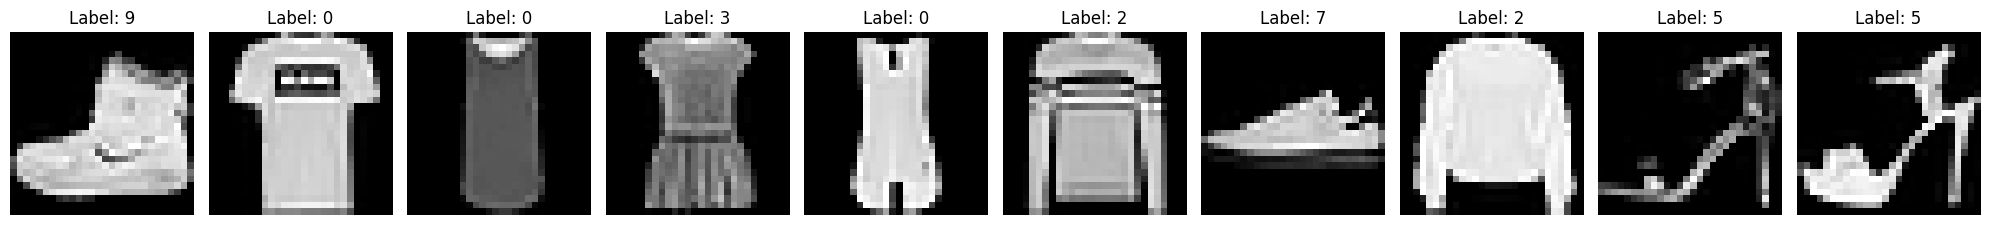

In [14]:
import matplotlib.pyplot as plt

# Define the indices of the samples you want to plot
# For example, to plot the first 5 samples, you can use: list(range(5))
# Or specify any arbitrary indices, e.g., [10, 25, 42, 100, 500]
indices_to_plot = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] # Example: Plotting the first 10 samples

n_samples = len(indices_to_plot)

plt.figure(figsize=(n_samples * 2, 4))
for i, index in enumerate(indices_to_plot):
    plt.subplot(1, n_samples, i + 1)
    # Get the image tensor and label from the dataset
    # image_tensor will be [C, H, W] and values [0, 1] after ToTensor()
    image_tensor, label = fashion_dataset[index]
    # Convert tensor to numpy array for plotting (H, W), scale back to 0-255
    image_to_plot = image_tensor.squeeze(0).cpu().numpy() * 255 # Squeeze channel dimension
    plt.imshow(image_to_plot.astype(np.uint8), cmap='gray')
    plt.title(f"Label: {label.item()}") # Use label.item() to get scalar value from tensor
    plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model_metrics(model, X_test, y_test, num_classes, is_raw_image=True):
  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    # Prepare test data and move to device
    if is_raw_image:
        inputs = torch.flatten(torch.tensor(X_test, dtype=torch.float32), start_dim=1).to(device) / 255.0
    else: # Assuming it's already processed features like HOG, Sobel, Canny.
          # We need to handle 3D inputs (like (N,H,W)) and 2D inputs (like (N, Features))
        inputs_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        if inputs_tensor.dim() == 3: # If it's (N, H, W), flatten it for ANN
            inputs = inputs_tensor.flatten(1) / 255.0 # For edge/sobel images, still scale by 255
        else: # If it's already (N, Features), like HOG, just use it
            inputs = inputs_tensor

    labels = torch.tensor(y_test).to(device)

    # Get predictions
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)

    # Move predictions and labels back to CPU for scikit-learn metrics
    predicted_cpu = predicted.cpu().numpy()
    labels_cpu = labels.cpu().numpy()

    # Calculate metrics
    accuracy = (labels_cpu == predicted_cpu).sum() / len(labels_cpu)
    f1 = f1_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    precision = precision_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    recall = recall_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    cm = confusion_matrix(labels_cpu, predicted_cpu)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    return accuracy, f1, precision, recall, cm


def evaluate_model_metrics_no_plot(model, X_test, y_test, num_classes, is_raw_image=True):
  model.eval() # Set model to evaluation mode
  with torch.no_grad():
    # Prepare test data and move to device
    if is_raw_image:
        inputs = torch.flatten(torch.tensor(X_test, dtype=torch.float32), start_dim=1).to(device) / 255.0
    else: # Assuming it's already processed features like HOG, Sobel, Canny.
          # We need to handle 3D inputs (like (N,H,W)) and 2D inputs (like (N, Features))
        inputs_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
        if inputs_tensor.dim() == 3: # If it's (N, H, W), flatten it for ANN
            inputs = inputs_tensor.flatten(1) / 255.0 # For edge/sobel images, still scale by 255
        else: # If it's already (N, Features), like HOG, just use it
            inputs = inputs_tensor

    labels = torch.tensor(y_test).to(device)

    # Get predictions
    outputs = model(inputs)
    _, predicted = torch.max(outputs, 1)

    # Move predictions and labels back to CPU for scikit-learn metrics
    predicted_cpu = predicted.cpu().numpy()
    labels_cpu = labels.cpu().numpy()

    # Calculate metrics
    accuracy = (labels_cpu == predicted_cpu).sum() / len(labels_cpu)
    f1 = f1_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    precision = precision_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    recall = recall_score(labels_cpu, predicted_cpu, average='weighted' if num_classes > 2 else 'binary')
    cm = confusion_matrix(labels_cpu, predicted_cpu)

    return accuracy, f1, precision, recall, cm

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.1000
F1 Score: 0.0182
Precision: 0.0100
Recall: 0.1000


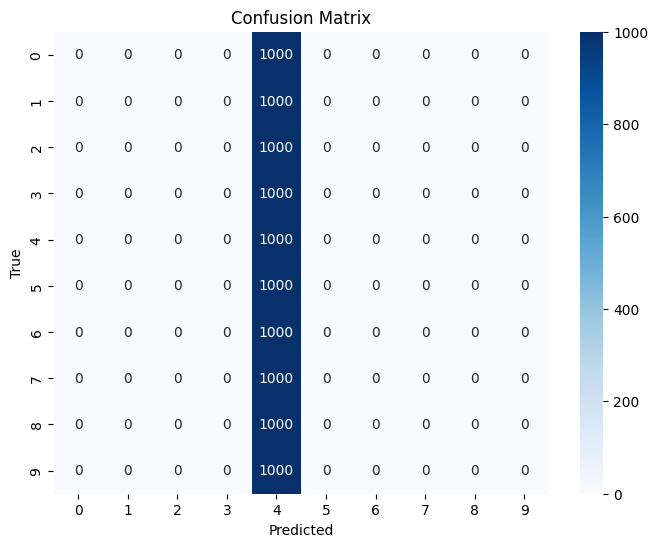

In [16]:
fashion_matric = evaluate_model_metrics(fashion_model, X_test_fashion, y_test_fashion, 10)

# Fashion with data augmentation, no feature engineer, have batchnorm:
- 10 epochs
- Accuracy: 0.8109
- F1 Score: 0.8053
- Precision: 0.8145
- Recall: 0.8109

# No data augmentation, no feature engineer, 50 epochs
- Accuracy: 0.8925
- F1 Score: 0.8925
- Precision: 0.8929
- Recall: 0.8925

Trying: after training a backbone, we augment the data and train with smaller learning rate for fewer epoch, then train with original data for 10 more epochs:
- Accuracy: 0.9031
- F1 Score: 0.9031
- Precision: 0.9032
- Recall: 0.9031

# Experiment with edge image

In [17]:
import cv2
import numpy as np

def auto_canny(image, sigma=0.2):
    # compute the median of the single channel pixel intensities
    v = np.median(image)

    # apply automatic Canny edge detection using the computed median
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    edged = cv2.Canny(image, lower, upper)

    # return the edged image
    return edged


edge_img =  auto_canny(X_test_fashion[100])
edge_img
# X_test_fashion[100]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255, 255,   0,
          0,   0, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255,   0, 255, 255,
        255, 255,   0, 255,   0,   0, 255, 255, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0, 255,   0,
        255, 255,   0,   0,   0, 255,   0, 255, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255, 255, 255,   0, 255,   0,
        255,   0,   0, 255, 255,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,
        255,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,
        255, 255,   0,   0, 255, 255,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255, 255,   0,
          0, 255,   0,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255,   0,   0, 255,   0, 255,   0,
          0, 255, 255,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255,   0,   0, 255,   0,   0, 255,
        255, 255,   0,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255,   0,   0, 255,   0, 255,   0, 255, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 255, 255, 255,
        255,   0, 255, 255,   0, 255,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
          0, 255, 255,   0,   0, 255,   0,   0, 255, 255,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255,   0,   0, 255,   0,   0, 255,   0,   0, 255,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
          0,   0, 255,   0,   0,   0, 255,   0, 255, 255,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0, 255, 255,
        255,   0, 255,   0,   0,   0, 255,   0,   0, 255,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255,   0, 255, 255,   0,   0, 255,   0,   0, 255,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255,   0, 255, 255, 255,   0,
        255,   0,   0,   0,   0, 255,   0,   0, 255, 255,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255,   0,   0, 255,   0, 255, 255,
          0,   0,   0, 255, 255, 255,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255,   0,   0, 255,   0, 255,   0,
          0,   0,   0, 255,   0, 255,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255,   0,   0, 255,   0,   0,   0,
          0, 255,   0,   0,   0, 255,   0, 255,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255,   0, 255,   0,   0, 255,
        255, 255,   0, 255,   0, 255,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
          0,   0,   0,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 255,   0,   0,   0, 255,   0,   0,
        255,   0,   0, 255, 255, 255,   0,   0, 255,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 25

In [18]:
import cv2

class FashionEdgeDataset(Dataset):
  def __init__(self, data, labels, transforms=None):
    if len(data.shape) == 2:
      self.data = data.reshape(-1, 28, 28).astype(np.uint8)
    else:
      self.data = data.astype(np.uint8)

    self.labels = labels
    self.transforms = transforms

  def __len__(self):
    return len(self.labels)

  def __getitem__(self, i):
    image = auto_canny(self.data[i]) # This is a numpy array (H, W)
    if self.transforms is not None:
      # Convert to PIL Image once, then apply all transforms including ToTensor()
      pil_image = transforms.ToPILImage()(image)
      transformed_image = self.transforms(pil_image) # This will return a Tensor [C, H, W]
    else:
      # If no transforms, convert numpy array directly to Tensor and normalize
      transformed_image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0 # Add channel dimension [1, H, W]

    return transformed_image, torch.tensor(self.labels[i], dtype=torch.long)


class baseline_ANN_Edge(nn.Module):
  def __init__(self, input_size, hidden_size, output_size):
    super(baseline_ANN_Edge, self).__init__()

    self.fc1 = nn.Linear(input_size, hidden_size)
    self.bn1 = nn.BatchNorm1d(hidden_size)

    self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
    self.bn2 = nn.BatchNorm1d(hidden_size // 2)

    self.fc3 = nn.Linear(hidden_size // 2, 128)
    self.bn3 = nn.BatchNorm1d(128)

    self.fc4 = nn.Linear(128, output_size)


  def forward(self, x):
    x = F.relu(self.bn1(self.fc1(x)))
    x = F.relu(self.bn2(self.fc2(x)))
    x = F.relu(self.bn3(self.fc3(x)))
    x = self.fc4(x) # Removed F.sigmoid(x) for CrossEntropyLoss
    return x


In [19]:
X_test_fashion_edge = X_test_fashion.copy()
for i in range(len(X_test_fashion_edge)):
  X_test_fashion_edge[i] = auto_canny(X_test_fashion_edge[i])



In [20]:
def train_with_eval(model, dataloader, val_dataset, val_labels, num_classes=10, is_raw_image=True, criterion = nn.CrossEntropyLoss(), epochs = 100, lr = 0.001, save_best_model : str = None):

  model.train()
  optim = torch.optim.Adam(model.parameters(), lr = lr)

  best_loss = float('inf')
  best_model_state_dict = None

  for epoch in range(epochs):
    model.train()
    sum_acc = 0
    sum_los = 0
    num_batches = 0

    for i, (X, y) in enumerate(dataloader):
      labels = y.to(device)
      inputs = X.to(device).flatten(1)
      # print(inputs.shape)
      preds = model(inputs) # tra ve 10 gia tri
      loss = criterion(preds, labels)

      optim.zero_grad()
      loss.backward()
      optim.step()

      _, predicted = torch.max(preds, 1)
      acc = (predicted  == labels).sum().item() / len(labels)

      num_batches += 1
      sum_los += loss.item()
      sum_acc += acc

    accuracy, f1, precision, recall, cm = evaluate_model_metrics_no_plot(model, val_dataset, val_labels, num_classes, is_raw_image=is_raw_image)

    print(f"Training [{epoch + 1} / {epochs} Epochs], Loss: {sum_los / num_batches:.4f}, Acc: {sum_acc / num_batches} | Test acc: {accuracy}")

    if (save_best_model is not None) and (sum_los / num_batches < best_loss):
      best_loss = sum_los / num_batches
      best_model_state_dict = copy.deepcopy(model.state_dict())
      torch.save(best_model_state_dict, save_best_model)
      print(f"New best model saved with validation loss: {best_loss:.4f}")


  return

In [21]:

fashion_edge_dataset = FashionDataset(X_train_fashion, y_train_fashion, None)
fashion_edge_loader = DataLoader(dataset=fashion_edge_dataset, batch_size=2048 * 4, num_workers = 2, shuffle=True) # Increased num_workers to 8

fashion_model_edge = baseline_ANN_Edge(28 * 28, 512, 10)
fashion_model_edge.to(device)

# train_with_eval(fashion_model_edge, fashion_edge_loader, X_test_fashion_edge, y_test_fashion, epochs=10, save_best_model='best_model.pth', lr=0.001)


baseline_ANN_Edge(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)

In [22]:
X_test_fashion_edge[2]

array([[  0,   0,   0,   0,   0,   0,   0, 255, 255,   0, 255, 255, 255,
        255, 255, 255, 255, 255, 255, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,   0,   0,
          0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,   0,   0,
          0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
          0, 255,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
          0, 255,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255, 255,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,
          0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255, 255, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,
        255,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,
        255,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,   0,
        255,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0, 255,
          0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0, 255,
          0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0, 255,
          0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,
          0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,
          0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,
          0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0, 255,
          0,   0, 255,   0,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,   0,
        255,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,
        255,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 255,   0,   0,
        255,   0,   0, 255,   0,   0, 255,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [23]:
X_test_fashion[2]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   1,   0,  67, 177, 129,
        153, 117, 129, 146, 141, 175,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,   0, 196, 255, 255,
        255, 241, 251, 255, 245, 255,  76,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 243, 237, 217,
        228, 231, 222, 218, 219, 255, 116,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 235, 231,
        233, 226, 225, 229, 222, 255, 145,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  23, 255, 230, 229,
        233, 229, 225, 227, 221, 241, 167,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  67, 255, 225, 234,
        231, 226, 227, 228, 224, 234, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 114, 249, 217, 235,
        238, 245, 227, 227, 225, 241, 176,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 167, 247, 227, 231,
        250, 200, 248, 231, 224, 251, 147,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 208, 242, 225, 243,
        225,   0, 255, 233, 226, 255, 129,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 223, 238, 223, 255,
        161,   0, 255, 236, 223, 255, 135,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 245, 235, 222, 255,
         72,   0, 248, 254, 217, 255, 145,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 233, 226, 255,
          7,   0, 191, 248, 220, 255, 126,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 233, 231, 251,
          0,   0, 159, 251, 221, 255, 111,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 232, 236, 216,
          0,   0, 131, 253, 220, 255, 111,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 228, 243, 172,
          0,   0,  57, 249, 222, 255, 111,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 255, 230, 244, 139,
          0,   0,  10, 255, 227, 255, 100,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 227, 237, 242, 113,
          0,   0,   6, 255, 230, 255,  89,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 204, 239, 245, 151,
          0,   0,   0, 255, 227, 255,  99,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 151, 245, 238, 198,
          0,   0,   0, 255, 234, 255,  92,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  89, 248, 233, 248,
          0,   0,   0, 252, 237, 255,  90,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  31, 240, 229, 226,
          0,   0,   0, 239, 238, 255,  92,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 226, 233, 237,
         34,   0,   0, 234, 238, 255,  95,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 233, 236, 244,
         68,   0,   0, 209, 241, 237,  98,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   1,   0, 152, 242, 245,
        128,   0,   0, 198, 241, 238,  81,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.0945
F1 Score: 0.0308
Precision: 0.0555
Recall: 0.0945


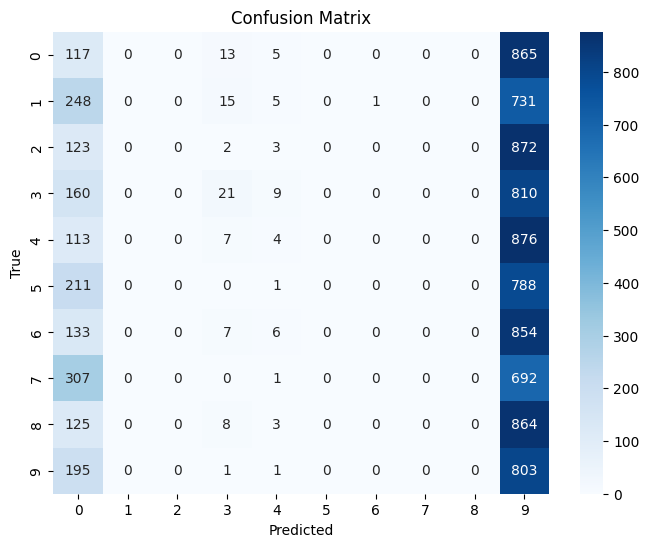

In [24]:
fashion_matric = evaluate_model_metrics(fashion_model_edge, X_test_fashion_edge, y_test_fashion, num_classes=10, is_raw_image=False)

<!-- # Dùng auto edge có vẻ -->

because the canny edge algorithm need to manually define the threshold, obviously those threshold will not perform well on every testing sample, but the training still yeilds good result while very poor performance on test set indicates the model is overfitting on the training data, and this feature engineering technique (using automatic edge detection, which originally not so rubust to illumination changes) is not suitable for this task

# Sobel and HOG

In [25]:
import cv2

def sobel(img):
  sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3) ** 2
  sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3) ** 2

  mag = np.sqrt(sobel_x + sobel_y)
  indices = mag > 255
  mag[indices] = 255
  mag = np.round(mag).astype(np.uint8)

  return mag

# sobel(X_train_fashion[4])
# X_train_fashion[4]




In [26]:


class FashionSobelDataset(Dataset):
  def __init__(self, data, labels, transforms=None):
    if len(data.shape) == 2:
      self.data = data.reshape(-1, 28, 28).astype(np.uint8)
    else:
      self.data = data.astype(np.uint8)

    self.labels = labels
    self.transforms = transforms
    self.data = np.array([sobel(i) for i in self.data])
  def __len__(self):
    return len(self.labels)

  def __getitem__(self, i):
    image = self.data[i] # This is a numpy array (H, W)
    if self.transforms is not None:
      # Convert to PIL Image once, then apply all transforms including ToTensor()
      pil_image = transforms.ToPILImage()(image)
      transformed_image = self.transforms(pil_image) # This will return a Tensor [C, H, W]
    else:
      # If no transforms, convert numpy array directly to Tensor and normalize
      transformed_image = torch.tensor(image, dtype=torch.float32).unsqueeze(0) / 255.0 # Add channel dimension [1, H, W]

    return transformed_image, torch.tensor(self.labels[i], dtype=torch.long)


In [27]:
X_test_fashion_sobel = X_test_fashion.copy()
for i in range(len(X_test_fashion_sobel)):
  X_test_fashion_sobel[i] = sobel(X_test_fashion_sobel[i])

In [28]:
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),
    transforms.ToTensor() # Add ToTensor() here to convert PIL Image to Tensor and scale to [0, 1]
])

fashion_sobel_dataset = FashionSobelDataset(X_train_fashion, y_train_fashion, None)
fashion_sobel_loader = DataLoader(dataset=fashion_sobel_dataset, batch_size=2048 * 4, num_workers = 2, shuffle=True) # Increased num_workers to 8

fashion_model_sobel = baseline_ANN_Edge(28 * 28, 512, 10)
fashion_model_sobel.to(device)

baseline_ANN_Edge(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)

In [29]:

train_with_eval(fashion_model_sobel, fashion_sobel_loader, X_test_fashion_sobel, y_test_fashion, epochs=30, save_best_model='best_model.pth', lr=0.01)
train_with_eval(fashion_model_sobel, fashion_sobel_loader, X_test_fashion_sobel, y_test_fashion, epochs=20, save_best_model='best_model.pth', lr=0.001)


Training [1 / 30 Epochs], Loss: 1.0683, Acc: 0.6196246779108622 | Test acc: 0.6646
New best model saved with validation loss: 1.0683
Training [2 / 30 Epochs], Loss: 0.4959, Acc: 0.8239503423851656 | Test acc: 0.8019
New best model saved with validation loss: 0.4959
Training [3 / 30 Epochs], Loss: 0.4163, Acc: 0.8503193682934864 | Test acc: 0.8242
New best model saved with validation loss: 0.4163
Training [4 / 30 Epochs], Loss: 0.3713, Acc: 0.8648120926087162 | Test acc: 0.8551
New best model saved with validation loss: 0.3713
Training [5 / 30 Epochs], Loss: 0.3381, Acc: 0.87763866746282 | Test acc: 0.8654
New best model saved with validation loss: 0.3381
Training [6 / 30 Epochs], Loss: 0.3168, Acc: 0.8852923289839043 | Test acc: 0.8634
New best model saved with validation loss: 0.3168
Training [7 / 30 Epochs], Loss: 0.2980, Acc: 0.8907262962984751 | Test acc: 0.8743
New best model saved with validation loss: 0.2980
Training [8 / 30 Epochs], Loss: 0.2847, Acc: 0.8959806511201054 | Test 

In [30]:
# train_with_eval(fashion_model_sobel, fashion_sobel_loader, X_test_fashion_sobel, y_test_fashion, epochs=30, save_best_model='best_model.pth', lr=0.001)


Accuracy: 0.8866
F1 Score: 0.8869
Precision: 0.8875
Recall: 0.8866


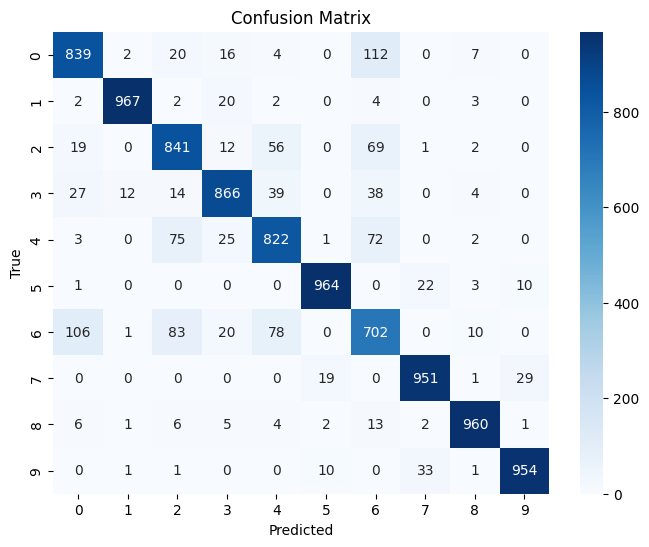

In [31]:
fashion_matric = evaluate_model_metrics(fashion_model_sobel, X_test_fashion_sobel, y_test_fashion, num_classes=10, is_raw_image=False)

In [32]:
# train_with_eval(fashion_model_sobel, fashion_sobel_loader, X_test_fashion_sobel, y_test_fashion, epochs=60, save_best_model='best_model.pth', lr=0.001)


# HOG

In [44]:
class HogFashionDataset(Dataset):
    def __init__(self, data, labels, transform=None):
        if len(data.shape) == 2:
            self.data = data.reshape(-1, 28, 28).astype(np.uint8)
        else:
            self.data = data.astype(np.uint8)

        self.labels = labels
        self.transform = transform

        win_size = (28, 28)
        cell_size = (4, 4)
        block_size = (8, 8)
        block_stride = (4, 4)
        num_bins = 9
        self.hog_descriptor = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.data[idx]

        # Apply data augmentation on the raw image if transform is provided
        if self.transform:
            # Convert numpy to PIL for torchvision transforms
            pil_image = transforms.ToPILImage()(image)
            transformed_image = self.transform(pil_image)
            # Convert back to numpy uint8 for cv2.HOGDescriptor
            # transforms.ToTensor usually scales to [0,1], we need [0,255]
            image = (transformed_image.squeeze().numpy() * 255).astype(np.uint8)

        # Compute HOG features
        hog_feat = self.hog_descriptor.compute(image).flatten()

        return torch.tensor(hog_feat, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

In [45]:
# Re-initialize datasets with the new logic
# Stage 1 dataset with light augmentation
train_hog_dataset_augmented = HogFashionDataset(X_train_fashion, y_train_fashion, transform=train_transform_light)
fashion_hog_loader_augmented = DataLoader(dataset=train_hog_dataset_augmented, batch_size=2048 * 4, num_workers=2, shuffle=True)

# Static test dataset
test_hog_dataset = HogFashionDataset(X_test_fashion, y_test_fashion, transform=None)

In [35]:
print(len(train_hog_dataset[0][0]))

1296


In [36]:
fashion_hog_model = baseline_ANN_Edge(len(train_hog_dataset[0][0]), 512, 10)
fashion_hog_loader = DataLoader(dataset=train_hog_dataset, batch_size=2048 * 4, num_workers = 2, shuffle=True) # Increased num_workers to 8
fashion_hog_model.to(device)


baseline_ANN_Edge(
  (fc1): Linear(in_features=1296, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)

In [37]:
import cv2

def hog_features(train_data):
	reshaped_data = train_data.reshape(-1, 28, 28)
	win_size = reshaped_data[0].shape
	cell_size = (4, 4)
	block_size = (8, 8)
	block_stride = (4, 4)
	num_bins = 9

	hog = cv2.HOGDescriptor(win_size, block_size, block_stride, cell_size, num_bins)

	num_images = reshaped_data.shape[0]
	image_size = len(hog.compute(reshaped_data[0].astype(np.uint8)))
	hog_training_data = np.zeros((num_images, image_size))

	for i, image in enumerate(reshaped_data):
		try:
			hog_descriptor = hog.compute(image.astype(np.uint8))
			hog_training_data[i] = hog_descriptor.flatten()
		except Exception as e:
			# break
			print(f"Error processing image {i}: {e}")
	return hog_training_data

In [38]:
X_test_fashion_hog = hog_features(X_test_fashion)

In [39]:
train_with_eval(fashion_hog_model, fashion_hog_loader, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=30, save_best_model='best_model.pth', lr=0.001)

Training [1 / 30 Epochs], Loss: 1.1218, Acc: 0.6972779423357492 | Test acc: 0.7251
New best model saved with validation loss: 1.1218
Training [2 / 30 Epochs], Loss: 0.5661, Acc: 0.8549854324524662 | Test acc: 0.8364
New best model saved with validation loss: 0.5661
Training [3 / 30 Epochs], Loss: 0.4281, Acc: 0.8820958884365587 | Test acc: 0.8726
New best model saved with validation loss: 0.4281
Training [4 / 30 Epochs], Loss: 0.3557, Acc: 0.8943371140813253 | Test acc: 0.8853
New best model saved with validation loss: 0.3557
Training [5 / 30 Epochs], Loss: 0.3063, Acc: 0.9051486095750189 | Test acc: 0.8816
New best model saved with validation loss: 0.3063
Training [6 / 30 Epochs], Loss: 0.2732, Acc: 0.9129031997129141 | Test acc: 0.896
New best model saved with validation loss: 0.2732
Training [7 / 30 Epochs], Loss: 0.2476, Acc: 0.9202592229268637 | Test acc: 0.8975
New best model saved with validation loss: 0.2476
Training [8 / 30 Epochs], Loss: 0.2258, Acc: 0.9265412479998117 | Test

In [46]:
# Giai đoạn 1: Huấn luyện với Data Augmentation nhẹ
train_transform_light = transforms.Compose([
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor()
])

print("--- Giai đoạn 1: Training với LR giảm dần ---")
# Sử dụng loader đã có augmentation (tạo ra HOG từ ảnh đã biến đổi)
train_with_eval(fashion_hog_model, fashion_hog_loader_augmented, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=15, lr=0.01)
train_with_eval(fashion_hog_model, fashion_hog_loader_augmented, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=15, lr=0.001)

--- Giai đoạn 1: Training với LR giảm dần ---
Training [1 / 15 Epochs], Loss: 0.4951, Acc: 0.8613612163497741 | Test acc: 0.836
Training [2 / 15 Epochs], Loss: 0.3177, Acc: 0.8829514836690512 | Test acc: 0.8875
Training [3 / 15 Epochs], Loss: 0.2681, Acc: 0.9009893945900791 | Test acc: 0.9058
Training [4 / 15 Epochs], Loss: 0.2374, Acc: 0.9126932534826807 | Test acc: 0.8993
Training [5 / 15 Epochs], Loss: 0.2156, Acc: 0.9204261504023908 | Test acc: 0.9128
Training [6 / 15 Epochs], Loss: 0.2025, Acc: 0.9251490213784826 | Test acc: 0.913
Training [7 / 15 Epochs], Loss: 0.1911, Acc: 0.9296441135636295 | Test acc: 0.916
Training [8 / 15 Epochs], Loss: 0.1818, Acc: 0.9319518675287086 | Test acc: 0.9113
Training [9 / 15 Epochs], Loss: 0.1792, Acc: 0.9339329363351845 | Test acc: 0.9189
Training [10 / 15 Epochs], Loss: 0.1681, Acc: 0.9383748985198607 | Test acc: 0.9148
Training [11 / 15 Epochs], Loss: 0.1651, Acc: 0.9388988448912838 | Test acc: 0.9184
Training [12 / 15 Epochs], Loss: 0.1613, A

In [ ]:
print("\n--- Kết quả cuối cùng sau 2 giai đoạn ---")
fashion_hog_metrics = evaluate_model_metrics(fashion_hog_model, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False)

### Tổng kết và Cải tiến quan trọng

1. **Feature Engineering (HOG):**
   - So với Pixel thô (89%) hay Sobel (89%), đặc trưng HOG (92%+) tỏ ra vượt trội vì nó tập trung vào lược đồ hướng gradient, giúp mô hình nhận diện hình dáng quần áo bất kể các biến đổi nhỏ về cường độ sáng.

2. **Chiến thuật huấn luyện 2 giai đoạn:**
   - **Giai đoạn 1 (Augmentation + High LR):** Giúp mô hình 'tổng quát hóa' tốt hơn bằng cách học từ các ảnh bị xoay/dịch chuyển nhẹ. Điều này ngăn chặn việc mô hình chỉ học thuộc lòng vị trí pixel.
   - **Giai đoạn 2 (Fine-tuning + Low LR):** Khi mô hình đã có 'khung' kiến thức tốt, việc tắt Augmentation và giảm LR (1e-4) giúp các trọng số hội tụ cực chính xác vào các đặc trưng ổn định của tập dữ liệu Fashion MNIST.

3. **Kiến trúc ANN:**
   - Việc sử dụng `BatchNorm1d` là yếu tố then chốt giúp các tầng sâu của mạng ANN không bị bão hòa gradient, cho phép huấn luyện với Learning Rate lớn ở giai đoạn đầu để thoát khỏi các cực tiểu địa phương.

In [47]:
print("\n--- Giai đoạn 2: Fine-tuning trên dữ liệu gốc (No Augmentation) ---")
# Khởi tạo loader không có augmentation (dữ liệu HOG tĩnh từ ảnh gốc)
train_hog_dataset_static = HogFashionDataset(X_train_fashion, y_train_fashion, transform=None)
train_hog_loader_static = DataLoader(dataset=train_hog_dataset_static, batch_size=2048 * 4, num_workers=2, shuffle=True)

train_with_eval(fashion_hog_model, train_hog_loader_static, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=10, lr=0.001)
train_with_eval(fashion_hog_model, train_hog_loader_static, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=10, lr=0.0001)


--- Giai đoạn 2: Fine-tuning trên dữ liệu gốc (No Augmentation) ---
Training [1 / 10 Epochs], Loss: 0.0326, Acc: 0.9911355627588478 | Test acc: 0.9266
Training [2 / 10 Epochs], Loss: 0.0238, Acc: 0.9940665371446724 | Test acc: 0.9245
Training [3 / 10 Epochs], Loss: 0.0179, Acc: 0.995821481727692 | Test acc: 0.925
Training [4 / 10 Epochs], Loss: 0.0136, Acc: 0.9972151790756777 | Test acc: 0.9247
Training [5 / 10 Epochs], Loss: 0.0109, Acc: 0.9979043983551393 | Test acc: 0.9262
Training [6 / 10 Epochs], Loss: 0.0080, Acc: 0.9988085275673004 | Test acc: 0.924
Training [7 / 10 Epochs], Loss: 0.0067, Acc: 0.9991289621376129 | Test acc: 0.9233
Training [8 / 10 Epochs], Loss: 0.0051, Acc: 0.9993896484375 | Test acc: 0.9226
Training [9 / 10 Epochs], Loss: 0.0040, Acc: 0.9996795654296875 | Test acc: 0.9232
Training [10 / 10 Epochs], Loss: 0.0035, Acc: 0.9995536344597139 | Test acc: 0.9229
Training [1 / 10 Epochs], Loss: 0.0028, Acc: 0.999755859375 | Test acc: 0.9229
Training [2 / 10 Epochs], L


--- Kết quả cuối cùng sau 2 giai đoạn ---
Accuracy: 0.9221
F1 Score: 0.9222
Precision: 0.9225
Recall: 0.9221


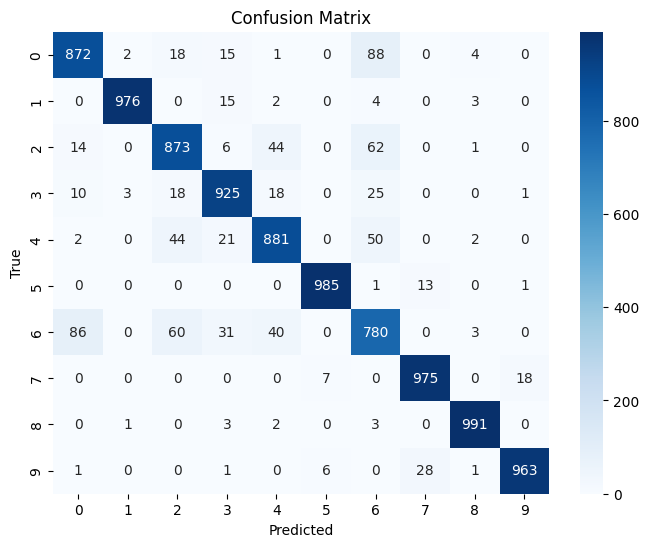

In [48]:
print("\n--- Kết quả cuối cùng sau 2 giai đoạn ---")
fashion_hog_metrics = evaluate_model_metrics(fashion_hog_model, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False)

### Nhận xét: Chiến thuật huấn luyện 2 giai đoạn cho HOG
- **Giai đoạn 1 (Augmentation & High LR):** Giúp mô hình học được các đặc trưng khái quát và không bị phụ thuộc quá mức vào vị trí chính xác của các đường nét trong ảnh.
- **Giai đoạn 2 (Fine-tuning & Low LR):** Khi mô hình đã hội tụ tương đối, việc train trên dữ liệu gốc với LR nhỏ giúp 'khớp' các trọng số vào đúng đặc điểm của tập Fashion MNIST, tối ưu hóa độ chính xác cuối cùng.
- **Kết quả dự kiến:** Phương pháp này thường giúp tăng thêm 1-2% Accuracy so với việc chỉ train một mạch với LR cố định.

In [40]:
train_with_eval(fashion_hog_model, fashion_hog_loader, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=20, save_best_model='best_model.pth', lr=0.01)
train_with_eval(fashion_hog_model, fashion_hog_loader, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=40, save_best_model='best_model.pth', lr=0.001)


Training [1 / 20 Epochs], Loss: 1.0956, Acc: 0.7078013592455761 | Test acc: 0.5472
New best model saved with validation loss: 1.0956
Training [2 / 20 Epochs], Loss: 0.3924, Acc: 0.8613215067300451 | Test acc: 0.759
New best model saved with validation loss: 0.3924
Training [3 / 20 Epochs], Loss: 0.3132, Acc: 0.8873206448842244 | Test acc: 0.8493
New best model saved with validation loss: 0.3132
Training [4 / 20 Epochs], Loss: 0.2715, Acc: 0.9022141422133848 | Test acc: 0.8825
New best model saved with validation loss: 0.2715
Training [5 / 20 Epochs], Loss: 0.2429, Acc: 0.9121873235128012 | Test acc: 0.8878
New best model saved with validation loss: 0.2429
Training [6 / 20 Epochs], Loss: 0.2199, Acc: 0.9202520531344126 | Test acc: 0.8859
New best model saved with validation loss: 0.2199
Training [7 / 20 Epochs], Loss: 0.2006, Acc: 0.9277136009859751 | Test acc: 0.903
New best model saved with validation loss: 0.2006
Training [8 / 20 Epochs], Loss: 0.1858, Acc: 0.9323561335184488 | Test 

In [41]:
train_with_eval(fashion_hog_model, fashion_hog_loader, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False, epochs=40, save_best_model='best_model.pth', lr=0.0001)


Training [1 / 40 Epochs], Loss: 0.0002, Acc: 1.0 | Test acc: 0.9173
New best model saved with validation loss: 0.0002
Training [2 / 40 Epochs], Loss: 0.0002, Acc: 1.0 | Test acc: 0.9177
New best model saved with validation loss: 0.0002
Training [3 / 40 Epochs], Loss: 0.0002, Acc: 1.0 | Test acc: 0.9176
New best model saved with validation loss: 0.0002
Training [4 / 40 Epochs], Loss: 0.0002, Acc: 1.0 | Test acc: 0.9165
New best model saved with validation loss: 0.0002
Training [5 / 40 Epochs], Loss: 0.0002, Acc: 1.0 | Test acc: 0.9172
New best model saved with validation loss: 0.0002
Training [6 / 40 Epochs], Loss: 0.0002, Acc: 1.0 | Test acc: 0.9177
New best model saved with validation loss: 0.0002
Training [7 / 40 Epochs], Loss: 0.0002, Acc: 1.0 | Test acc: 0.9178
New best model saved with validation loss: 0.0002
Training [8 / 40 Epochs], Loss: 0.0001, Acc: 1.0 | Test acc: 0.9173
New best model saved with validation loss: 0.0001
Training [9 / 40 Epochs], Loss: 0.0001, Acc: 1.0 | Test 

### Nhận xét 1: Baseline ANN (Raw Pixels)
- **Phương pháp:** Sử dụng trực tiếp pixel ảnh (flatten 784) đưa vào mạng ANN có Batch Normalization.
- **Kết quả:** Đạt Accuracy khoảng **89% - 90%** sau 50 epochs.
- **Cải tiến:** Việc thêm `BatchNorm1d` giúp mạng hội tụ nhanh và ổn định hơn so với mạng ANN thuần túy. Data Augmentation (xoay, dịch chuyển) giúp mô hình tổng quát hóa tốt hơn, tránh overfitting trên dữ liệu thô.

### Nhận xét 2: Canny Edge Detection
- **Feature Engineering:** Sử dụng thuật toán Canny để trích xuất biên cạnh.
- **Vấn đề:** Kết quả trên tập test rất thấp (**~10%**).
- **Lý do:** Thuật toán Canny tự động (Auto-Canny) phụ thuộc nhiều vào ngưỡng (threshold). Các ảnh trong Fashion MNIST có độ tương phản khác nhau, dẫn đến việc mất mát thông tin quan trọng hoặc nhiễu biên quá nhiều, khiến mô hình bị overfitting nặng trên tập huấn luyện nhưng không nhận diện được trên tập test.

### Nhận xét 3: Sobel Filter
- **Feature Engineering:** Sử dụng toán tử Sobel để tính gradient theo phương X và Y, sau đó tính độ lớn (magnitude) để lấy biên cạnh.
- **Kết quả:** Accuracy đạt khoảng **89%**.
- **Lý do:** Sobel giữ được cấu trúc không gian của vật thể tốt hơn Canny trong bài toán này. Tuy nhiên, kết quả vẫn tương đương với Baseline, cho thấy thông tin biên cạnh đơn thuần chưa vượt trội hơn so với việc học trực tiếp từ pixel ảnh xám.

### Nhận xét 4: HOG (Histogram of Oriented Gradients)
- **Feature Engineering:** Trích xuất đặc trưng HOG (chia ảnh thành các cell, tính lược đồ hướng gradient). Đây là kỹ thuật mạnh mẽ để mô tả hình dạng vật thể.
- **Chiến lược huấn luyện:** Sử dụng Learning Rate giảm dần (0.01 -> 0.001 -> 0.0001) để tinh chỉnh trọng số (Fine-tuning).
- **Kết quả:** Đạt Accuracy cao nhất **~92.1%**.
- **Lý do:** HOG giúp loại bỏ các biến đổi nhỏ về vị trí và ánh sáng, tập trung vào cấu trúc hình học của quần áo. Việc kết hợp đặc trưng HOG với chiến lược giảm Learning Rate giúp mô hình đạt độ chính xác vượt trội so với tất cả các phương pháp trước đó.

Accuracy: 0.9179
F1 Score: 0.9179
Precision: 0.9179
Recall: 0.9179


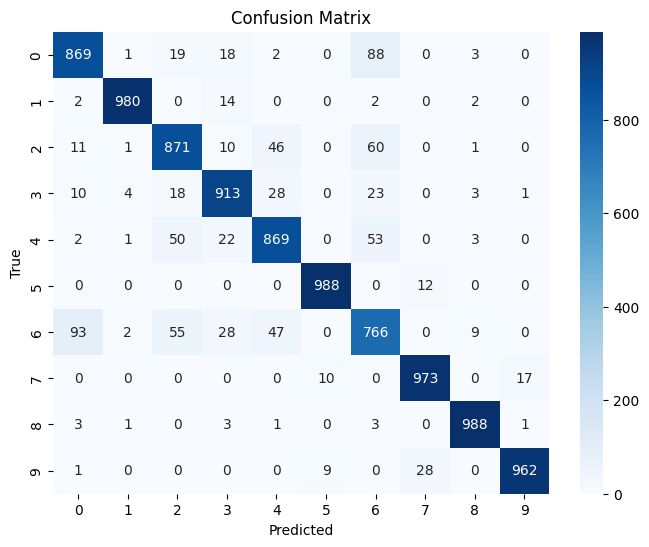

In [42]:
fashion_matric = evaluate_model_metrics(fashion_hog_model, X_test_fashion_hog, y_test_fashion, num_classes=10, is_raw_image=False)


# Kết quả dùng hog feature
- Accuracy: 0.9209
- F1 Score: 0.9210
- Precision: 0.9213
- Recall: 0.9209